## Objective

### To identify customers who are likely to leave the bank using a deep learning model (ANN).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix

# ANN using Scikit-learn
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance


In [9]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)


In [11]:
df.isnull().sum()


CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Encode Categorical Variables

In [3]:
# Label encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-Hot encode Geography
ct = ColumnTransformer(
    transformers=[('geo', OneHotEncoder(drop='first'), ['Geography'])],
    remainder='passthrough'
)

X = ct.fit_transform(df.drop('Exited', axis=1))
y = df['Exited']


### Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Feature Scaling

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Exploratory Data Analysis (EDA)

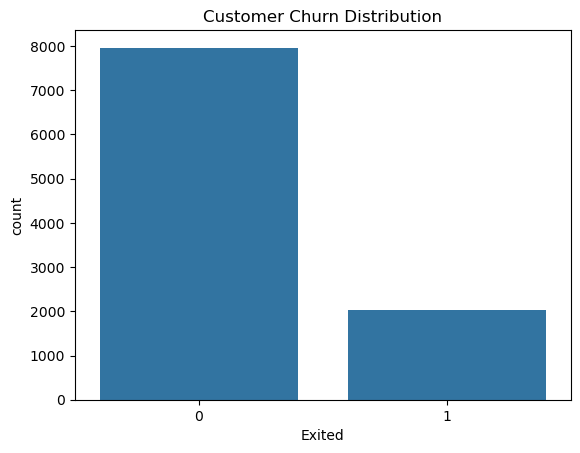

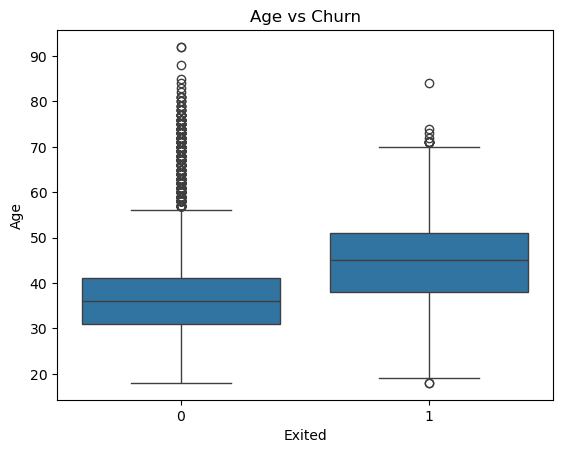

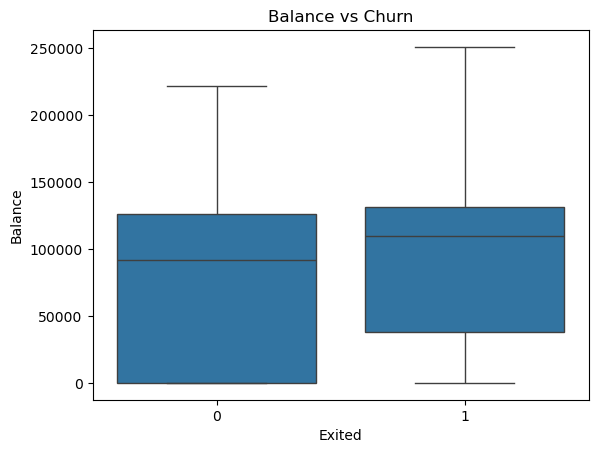

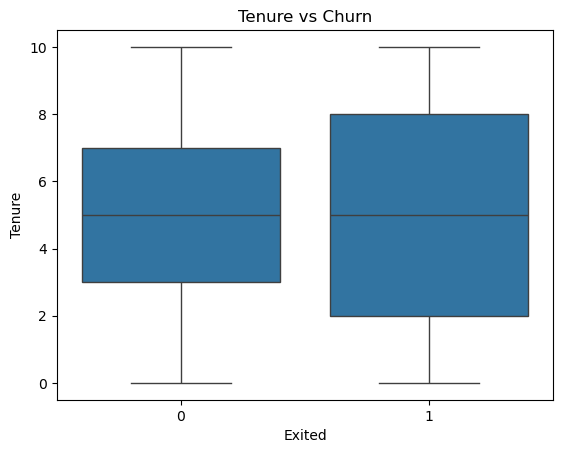

In [13]:
# Target distribution
sns.countplot(x='Exited', data=df)
plt.title("Customer Churn Distribution")
plt.show()

# Age vs Exited
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

# Balance vs Exited
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Balance vs Churn")
plt.show()

# Tenure vs Exited
sns.boxplot(x='Exited', y='Tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


### Train ANN Model

In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(11, 6),  # Two hidden layers: 11 and 6 neurons
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(11, 6), max_iter=500, random_state=42)

### Model Evaluation

In [7]:
y_pred = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8635
Confusion Matrix:
 [[1527   80]
 [ 193  200]]


### Feature Importance

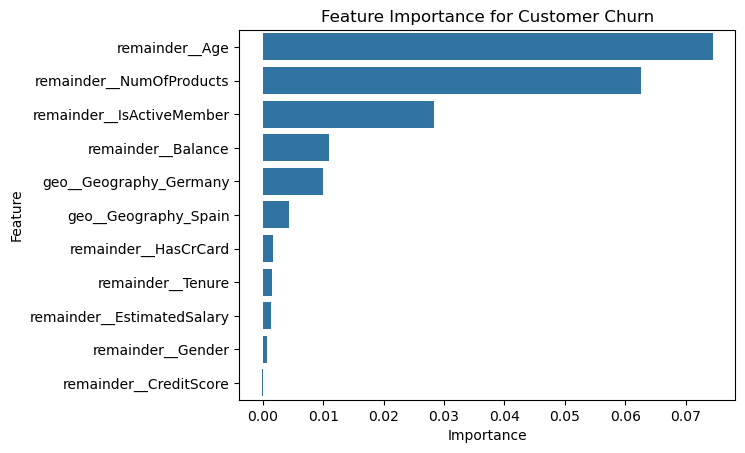

In [ ]:
r = permutation_importance(
    mlp, X_test, y_test,
    n_repeats=10,
    random_state=42
)

feature_names = ct.get_feature_names_out()

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': r.importances_mean
}).sort_values(by='Importance', ascending=False)

# Plot Feature Importance
sns.barplot(x='Importance', y='Feature', data=imp_df)
plt.title("Feature Importance for Customer Churn")
plt.show()
